In [1]:
# San Lam’s Python script

In [2]:
#import packages
import pandas as pd
import numpy as np
!python3 -m pip install matplotlib
import matplotlib.pyplot as plt
from matplotlib import ticker
import warnings

#update display options
pd.options.display.float_format = '{:.2f}'.format
warnings.filterwarnings("ignore")

In [3]:
#reusable functions

#summarize dataframe
def summarize(df, name="df"):
    print(f"Number of rows in {name}: ", len(df))
    print(f"Number of unique rows in {name}: ",len(df.drop_duplicates()))
    print()
    print(f"Non-null count and data types in {name}:")
    print(df.info())
    print()
    print(f"Summary stats of {name}:")
    print(df.describe())

#create two scatter plots given 2 x variables (columns) and 2 y variables (columns)
def create_scatter_plot(x1, y1, x2, y2, xlabel1, ylabel1, xlabel2, ylabel2, title1 = "plot1", title2 = "plot2"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    #plot1
    ax1.scatter(x1, y1, color='blue', alpha=0.5)
    ax1.set_title(title1)
    ax1.set_xlabel(xlabel1)
    ax1.set_ylabel(ylabel1)

    #plot2
    ax2.scatter(x2, y2, color='orange', marker='x')
    ax2.set_title(title2)
    ax2.set_xlabel(xlabel2)
    ax2.set_ylabel(ylabel2)

    plt.tight_layout()
    plt.show()

### 1) Please load the entire dataset

In [4]:
enrollments = pd.read_csv("enrollments.csv")
countries_gdp = pd.read_csv("Countries GDP 1960-2020.csv")

In [5]:
#As you perform this analysis, note any particular observations you have about the data within your script

#perform data exploration on enrollments dataset
summarize(enrollments, name="enrollments")

Number of rows in enrollments:  161560
Number of unique rows in enrollments:  161557

Non-null count and data types in enrollments:
<class 'pandas.DataFrame'>
RangeIndex: 161560 entries, 0 to 161559
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   country                 161560 non-null  str    
 1   countrycode             159698 non-null  str    
 2   region                  159698 non-null  str    
 3   incomegroup             159691 non-null  str    
 4   iau_id                  161553 non-null  str    
 5   iau_id1                 161553 non-null  str    
 6   eng_name                161553 non-null  str    
 7   orig_name               138446 non-null  str    
 8   foundedyr               161525 non-null  float64
 9   yrclosed                460 non-null     float64
 10  private01               161525 non-null  float64
 11  coordinates             138352 non-null  str    
 12  latitud

#### Response to Observations: 
There seem to be several columns in the enrollments dataset that have null values and values with non-standard 
formatting. There are also duplicate rows in the dataset. As a result, I will clean up the dataset before doing any analysis

In [6]:
#perform data clean up

#make a copy of the enrollments dataset to preserve original
enrollments_clean = enrollments.copy()

#drop duplicate rows
enrollments_clean = enrollments_clean.drop_duplicates()

#drop rows with mostly empty values (i.e., countries with '"' at the end of the name
enrollments_clean = enrollments_clean.loc[~enrollments_clean['country'].str.endswith('"')].reset_index(drop = True)

#add school type
enrollments_clean['school_type'] = np.where(enrollments_clean['private01'] == 1, 'private', 'public')

#check counts
print(len(enrollments_clean))
print(len(enrollments_clean.drop_duplicates()))

161532
161532


### 2) What civil or geopolitical events do you think you might be able to detect with this data set? Create one or more visualizations and some basic analysis to make some initial observations about this event as it impacted university enrollments. It is ok if the event turns out not to be observable in the data.

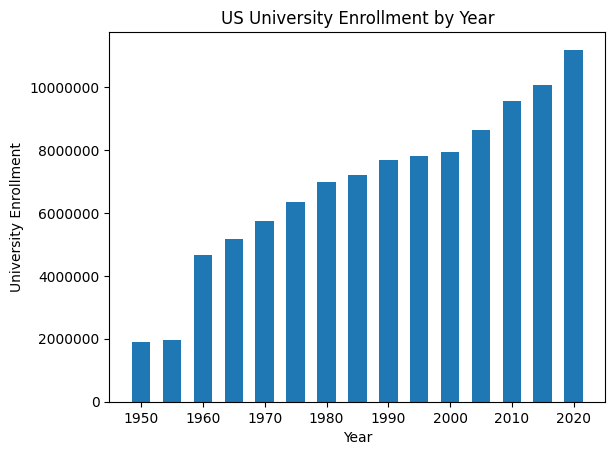

,year,students5_estimated,change
0,1950,1888236,nan%
1,1955,1965641,4.10%
2,1960,4653250,136.73%
3,1965,5159693,10.88%
4,1970,5741745,11.28%
5,1975,6358447,10.74%
6,1980,6968148,9.59%
7,1985,7210475,3.48%
8,1990,7673296,6.42%
9,1995,7806999,1.74%


In [7]:
#Vietnam War (1955-1975) / US protests
#Impacted countries/region(s): United States
#Hypothesis: US university enrollment increased due to US draft (particularly amongst men, though gender not shown in data)

#subset data to us enrollments only
us_enrollments = enrollments_clean.loc[enrollments_clean['countrycode'] == 'USA']

#group by year
us_enrollments_by_year = us_enrollments.groupby('year').agg({'students5_estimated':'sum'})
us_enrollments_by_year.reset_index(inplace = True)

#plot overall enrollment by year using bar chart
plt.bar(us_enrollments_by_year['year'], us_enrollments_by_year['students5_estimated'], width = 3)
plt.title("US University Enrollment by Year")
plt.xlabel('Year')
plt.ylabel('University Enrollment')
plt.ticklabel_format(style='plain', axis='both') 
plt.show()

#calculate 5-year growth 
us_enrollments_by_year['change'] = us_enrollments_by_year['students5_estimated'].pct_change(1)
us_enrollments_by_year.style.format({'year': '{:.0f}', 'students5_estimated': '{:.0f}', 'change': '{:.2%}'})

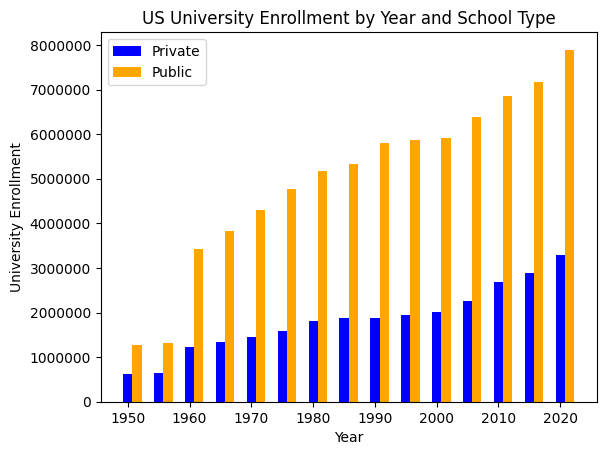

,year,school_type,students5_estimated,change
0,1950,private,614410,nan%
1,1950,public,1273826,nan%
2,1955,private,642783,4.62%
3,1955,public,1322858,3.85%
4,1960,private,1236070,92.30%
5,1960,public,3417180,158.32%
6,1965,private,1334473,7.96%
7,1965,public,3825220,11.94%
8,1970,private,1447013,8.43%
9,1970,public,4294732,12.27%


In [8]:
#group by year and school_type
us_year_school_type = us_enrollments.groupby(['year', 'school_type']).agg({'students5_estimated':'sum'})
us_year_school_type.reset_index(inplace = True)

#plot overall enrollment by school type and year using bar chart
ind = us_year_school_type['year'].drop_duplicates().reset_index(drop=True)
width = 1.5       

fig = plt.figure()
ax = fig.add_subplot(111)
rects1 = ax.bar(ind, us_year_school_type['students5_estimated'].loc[us_year_school_type['school_type'] == 'private'], width, color='blue')
rects2 = ax.bar(ind+width, us_year_school_type['students5_estimated'].loc[us_year_school_type['school_type'] == 'public'], width, color='orange')
ax.set_ylabel('University Enrollment')
ax.set_xlabel('Year')
ax.set_title('US University Enrollment by Year and School Type')
ax.legend( (rects1[0], rects2[0]), ('Private', 'Public') )
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

#calculate 5-year growth 
us_year_school_type['change'] = us_year_school_type['students5_estimated'].pct_change(2)
us_year_school_type.style.format({'year': '{:.0f}', 'students5_estimated': '{:.0f}', 'change': '{:.2%}'})

#### Response to Q2: 
Based on the university enrollment data, it would seem that the Vietnam War, which took place between 1955-1975, 
and the resulting protests from young Americans led to a spike in university enrollment between 1955 and 1960. We can see this 
based on the bar chart showing total "US University Enrollment by Year" as well as in the 5-year growth calculation in the table.
Additionally, when broken down by school type (private vs. public), most of this growth is driven by public school enrollment,
though both types of institutions see a growth spike. This spike in enrollment makes sense because young men in particular 
who did not want to fight in the war would often purse higher education to avoid the draft and public school was a much cheaper
and easier route to pursue. It would be interesting to see this data broken down by gender to see if the the growth in enrollment
was mostly driven by men as per my hypothesis.

### 3) Your client wants to know how GDP is related to university enrollment. Join the provided data set “Countries GDP 1960-2020.csv” onto the enrollments one and briefly describe the relationship you see.

In [9]:
#As you perform this analysis, note any particular observations you have about the data within your script

#perform data exploration on gdp dataset
summarize(countries_gdp, name="countries_gdp")

Number of rows in countries_gdp:  120
Number of unique rows in countries_gdp:  120

Non-null count and data types in countries_gdp:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 63 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  120 non-null    str    
 1   Country Code  120 non-null    str    
 2   1960          119 non-null    float64
 3   1961          120 non-null    float64
 4   1962          120 non-null    float64
 5   1963          120 non-null    float64
 6   1964          120 non-null    float64
 7   1965          120 non-null    float64
 8   1966          120 non-null    float64
 9   1967          120 non-null    float64
 10  1968          120 non-null    float64
 11  1969          120 non-null    float64
 12  1970          120 non-null    float64
 13  1971          120 non-null    float64
 14  1972          120 non-null    float64
 15  1973          120 non-null    float64


#### Response to Observations: 
The countries_gdp dataset is much smaller and cleaner with no duplicate rows and only one null value in 1960.

In [10]:
#join the provided data set “Countries GDP 1960-2020.csv” onto the enrollments one 

#reshape countries_gdp so that we can join on year
countries_gdp_reshaped = pd.melt(countries_gdp, id_vars = ["Country Name", "Country Code"])
countries_gdp_reshaped.rename(columns = {'variable':'year', 'value':'gdp'}, inplace = True)
countries_gdp_reshaped['year'] = countries_gdp_reshaped['year'].astype(float)

#since we are only concerned with countries where we have gdp info, do inner join
enroll_gdp = enrollments_clean.merge(countries_gdp_reshaped, how = 'inner', left_on = ['countrycode', 'year'], 
                                     right_on = ['Country Code', 'year'])

#subset to interested columns
enroll_gdp_sub = enroll_gdp[['country', 'countrycode', 'year', 'region', 'incomegroup', 'iau_id1', 'school_type', 'students5_estimated', 'gdp']]

#we retain 44.6% of the countries and 59% of the rows
print("% rows kept: ", np.round(100*(len(enroll_gdp_sub)/len(enrollments_clean)), 2))
print("% countries kept: ", np.round(100*(len(enroll_gdp_sub['countrycode'].drop_duplicates())/
                                          len(enrollments_clean['countrycode'].drop_duplicates())), 2))

% rows kept:  59.02
% countries kept:  44.68


East Asia and Pacific
                  total_gdp  total_enrollment
total_gdp              1.00              0.98
total_enrollment       0.98              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.97
avg_enrollment     0.97            1.00


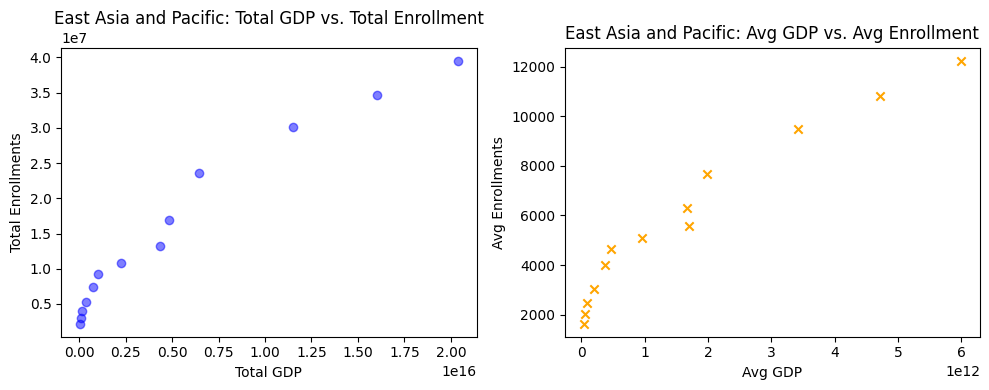


Europe and Central Asia
                  total_gdp  total_enrollment
total_gdp              1.00              0.98
total_enrollment       0.98              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.97
avg_enrollment     0.97            1.00


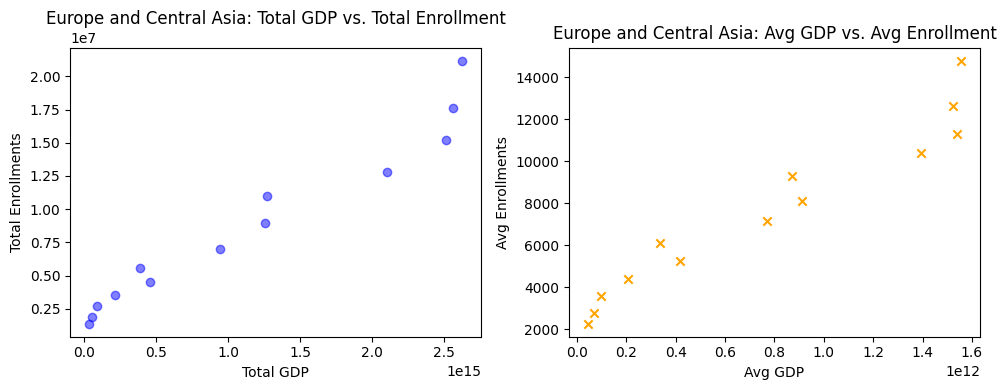


Latin America and Caribbean
                  total_gdp  total_enrollment
total_gdp              1.00              0.98
total_enrollment       0.98              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.92
avg_enrollment     0.92            1.00


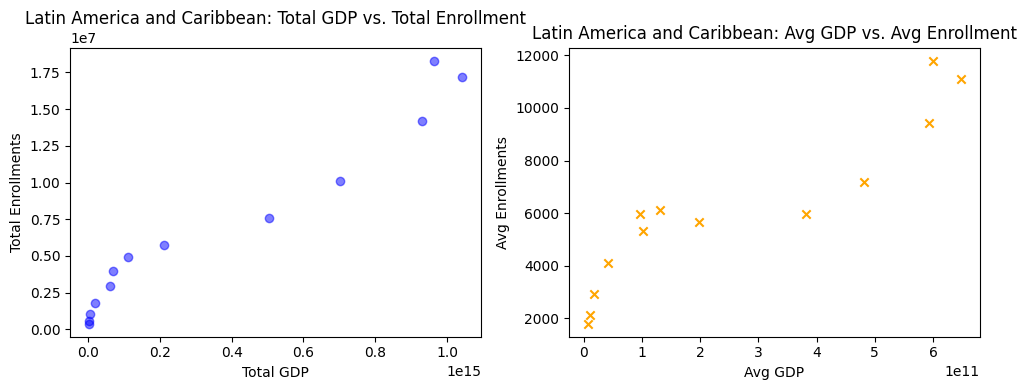


Middle East and North Africa
                  total_gdp  total_enrollment
total_gdp              1.00              0.96
total_enrollment       0.96              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.92
avg_enrollment     0.92            1.00


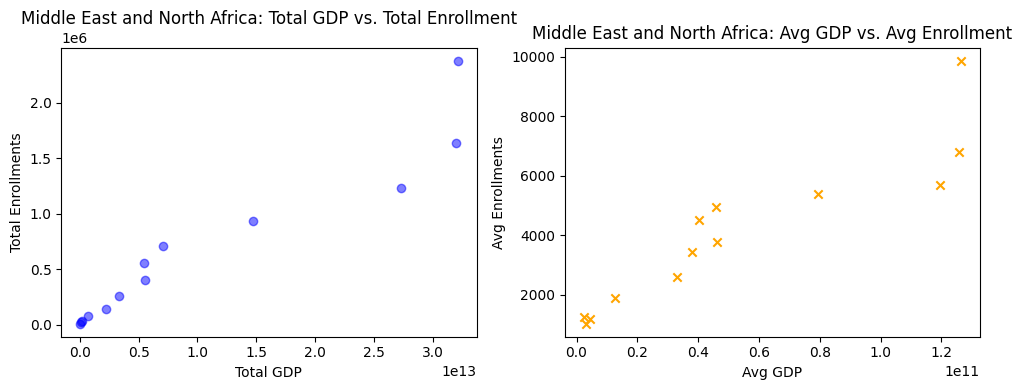


North America
                  total_gdp  total_enrollment
total_gdp              1.00              0.97
total_enrollment       0.97              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.98
avg_enrollment     0.98            1.00


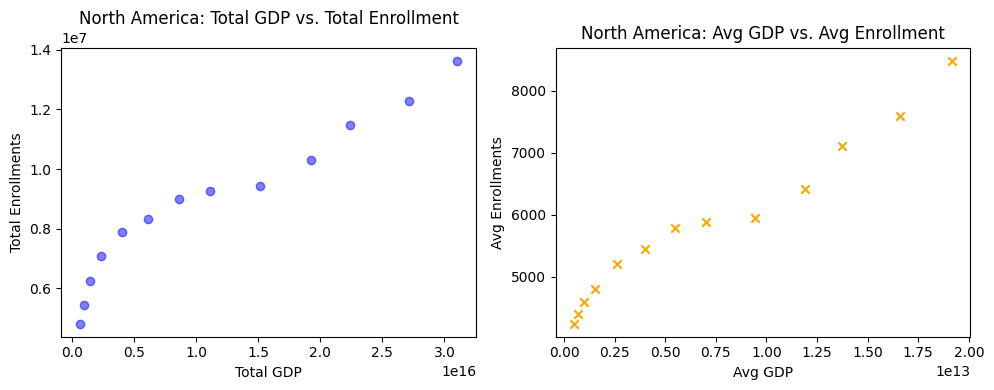


South Asia
                  total_gdp  total_enrollment
total_gdp              1.00              0.93
total_enrollment       0.93              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.65
avg_enrollment     0.65            1.00


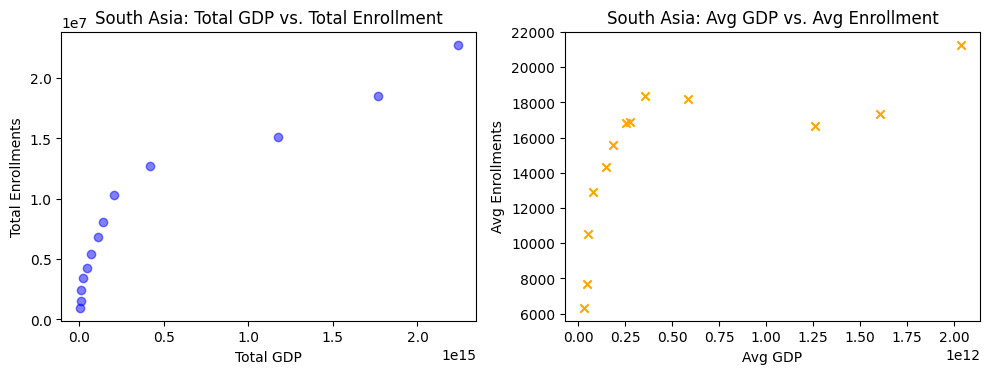


Sub-Saharan Africa
                  total_gdp  total_enrollment
total_gdp              1.00              0.97
total_enrollment       0.97              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.94
avg_enrollment     0.94            1.00


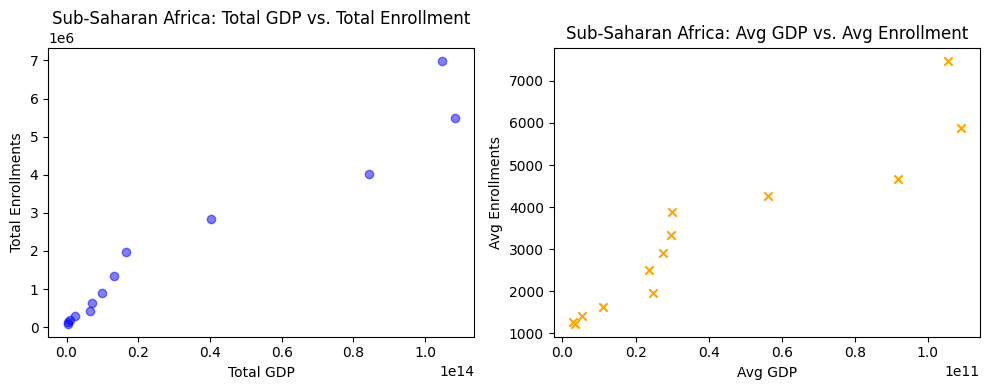

In [11]:
#check relationship between gdp and enrollment by region
regional_breakdown = enroll_gdp_sub.groupby(['region', 'year']).agg({'gdp':['sum', 'mean'], 
                                                'students5_estimated': ['sum', 'mean']})
regional_breakdown.reset_index(inplace = True)
regional_breakdown.columns = ['region', 'year', 'total_gdp', 'avg_gdp', 'total_enrollment', 'avg_enrollment']

#loop through regions and check correlation and plot data (both totals and averages)
for region in list(regional_breakdown['region'].drop_duplicates()):
    print(region)
    print(regional_breakdown[['total_gdp', 'total_enrollment']].loc[regional_breakdown['region'] == region].corr())
    print(regional_breakdown[['avg_gdp', 'avg_enrollment']].loc[regional_breakdown['region'] == region].corr())
    create_scatter_plot(regional_breakdown['total_gdp'].loc[regional_breakdown['region'] == region], 
                        regional_breakdown['total_enrollment'].loc[regional_breakdown['region'] == region], 
                        regional_breakdown['avg_gdp'].loc[regional_breakdown['region'] == region], 
                        regional_breakdown['avg_enrollment'].loc[regional_breakdown['region'] == region], 
                        "Total GDP", "Total Enrollments", "Avg GDP", "Avg Enrollments", 
                        title1 = region+ ": Total GDP vs. Total Enrollment", title2 = region + ": Avg GDP vs. Avg Enrollment")
    print()

High income
                  total_gdp  total_enrollment
total_gdp              1.00              0.99
total_enrollment       0.99              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.99
avg_enrollment     0.99            1.00


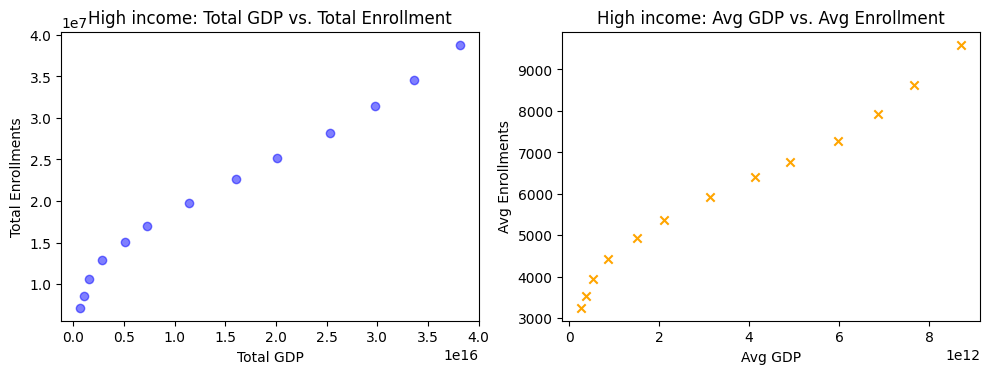


Low income
                  total_gdp  total_enrollment
total_gdp              1.00              0.96
total_enrollment       0.96              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.92
avg_enrollment     0.92            1.00


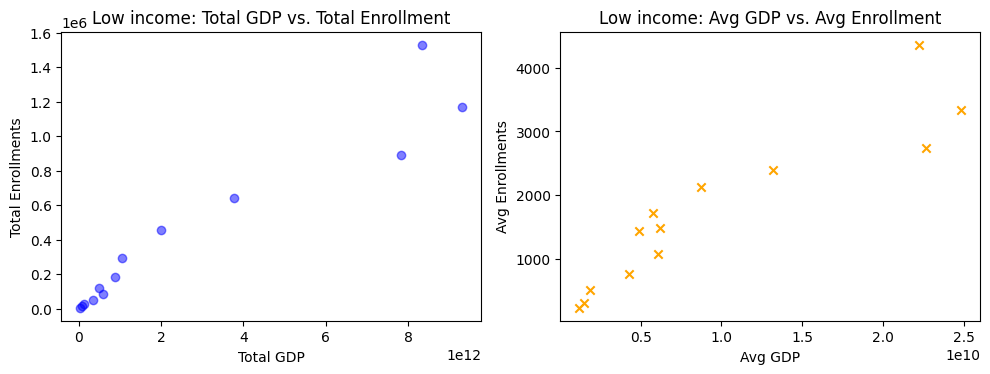


Lower middle income
                  total_gdp  total_enrollment
total_gdp              1.00              0.95
total_enrollment       0.95              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.86
avg_enrollment     0.86            1.00


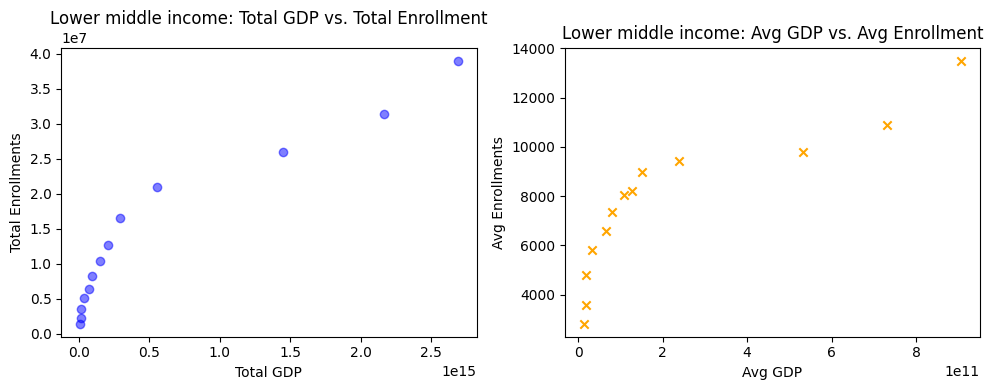


Upper middle income
                  total_gdp  total_enrollment
total_gdp              1.00              0.95
total_enrollment       0.95              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.93
avg_enrollment     0.93            1.00


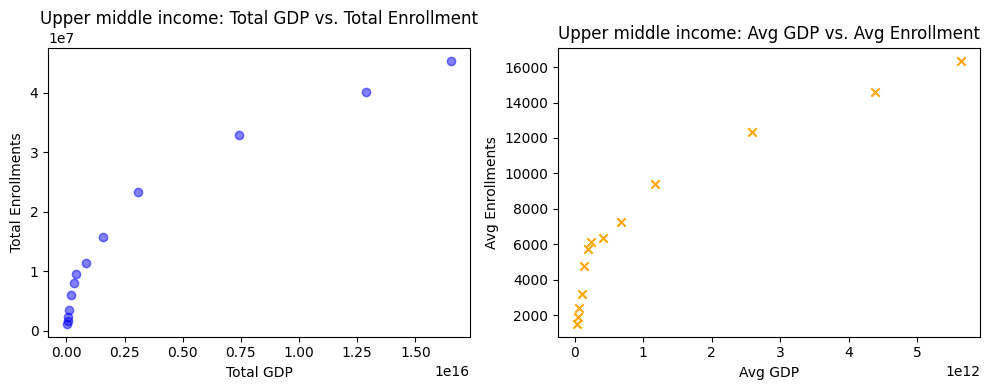

In [12]:
#check relationship between gdp and enrollment by incomegroup
income_breakdown = enroll_gdp_sub.groupby(['incomegroup', 'year']).agg({'gdp':['sum', 'mean'], 
                                                'students5_estimated': ['sum', 'mean']})
income_breakdown.reset_index(inplace = True)
income_breakdown.columns = ['incomegroup', 'year', 'total_gdp', 'avg_gdp', 'total_enrollment', 'avg_enrollment']

#loop through incomegroups and check correlation and plot data (both totals and averages)
for incomegroup in list(income_breakdown['incomegroup'].drop_duplicates()):
    print(incomegroup)
    print(income_breakdown[['total_gdp', 'total_enrollment']].loc[income_breakdown['incomegroup'] == incomegroup].corr())
    print(income_breakdown[['avg_gdp', 'avg_enrollment']].loc[income_breakdown['incomegroup'] == incomegroup].corr())
    create_scatter_plot(income_breakdown['total_gdp'].loc[income_breakdown['incomegroup'] == incomegroup], 
                        income_breakdown['total_enrollment'].loc[income_breakdown['incomegroup'] == incomegroup], 
                        income_breakdown['avg_gdp'].loc[income_breakdown['incomegroup'] == incomegroup], 
                        income_breakdown['avg_enrollment'].loc[income_breakdown['incomegroup'] == incomegroup], 
                        "Total GDP", "Total Enrollments", "Avg GDP", "Avg Enrollments", 
                        title1 = incomegroup+": Total GDP vs. Total Enrollment", title2 = incomegroup+": Avg GDP vs. Avg Enrollment")
    print()

private
                  total_gdp  total_enrollment
total_gdp              1.00              1.00
total_enrollment       1.00              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.97
avg_enrollment     0.97            1.00


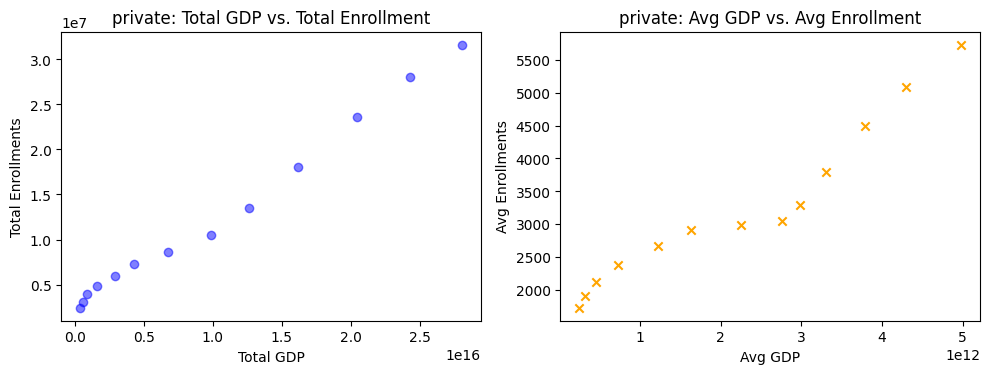


public
                  total_gdp  total_enrollment
total_gdp              1.00              0.99
total_enrollment       0.99              1.00
                avg_gdp  avg_enrollment
avg_gdp            1.00            0.99
avg_enrollment     0.99            1.00


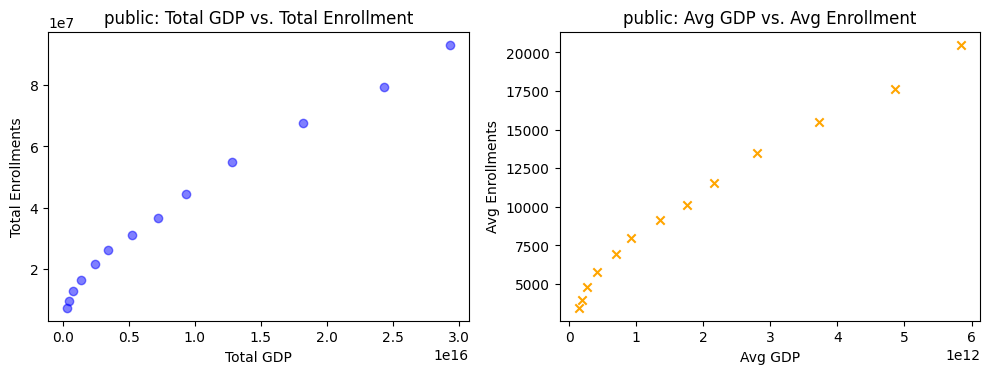

In [13]:
#check relationship between gdp and enrollment of private vs public
private_breakdown = enroll_gdp_sub.groupby(['school_type', 'year']).agg({'gdp':['sum', 'mean'], 
                                                'students5_estimated': ['sum', 'mean']})
private_breakdown.reset_index(inplace = True)
private_breakdown.columns = ['school_type', 'year', 'total_gdp', 'avg_gdp', 'total_enrollment', 'avg_enrollment']

#loop through school types and check correlation and plot data (both totals and averages)
for school_type in list(private_breakdown['school_type'].drop_duplicates()):
    print(school_type)
    print(private_breakdown[['total_gdp', 'total_enrollment']].loc[private_breakdown['school_type'] == school_type].corr())
    print(private_breakdown[['avg_gdp', 'avg_enrollment']].loc[private_breakdown['school_type'] == school_type].corr())
    create_scatter_plot(private_breakdown['total_gdp'].loc[private_breakdown['school_type'] == school_type], 
                        private_breakdown['total_enrollment'].loc[private_breakdown['school_type'] == school_type], 
                        private_breakdown['avg_gdp'].loc[private_breakdown['school_type'] == school_type], 
                        private_breakdown['avg_enrollment'].loc[private_breakdown['school_type'] == school_type], 
                        "Total GDP", "Total Enrollments", "Avg GDP", "Avg Enrollments", 
                        title1 = school_type+": Total GDP vs. Total Enrollment", title2 = school_type+": Avg GDP vs. Avg Enrollment")
    print()

#### Response to Q3: 
I see a positive relationship between GDP and university enrollment across the board based on correlations calculated
and the visualizations created. I broke the data down by region, income group, and institution type (private vs. public) and 
across all dimensions, a positive relationship is shown between GDP and university enrollment (both total and average). 
This makes sense given that education level likely affects GDP and vice versa (though this analysis only proves there is a 
relationship, not necessarily a causal one).

Note that I did not look at the data in full aggregate because I was concerned bigger countries would overpower the smaller ones 
and we would miss out on potential nuance. Addiitonally, I did not do the analysis by country because I felt the that would 
create too many data points to be useful to the client.